I had Claude cook most of these up, really convenient. 

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import ConnectionPatch

plt.rcParams.update({
    "text.usetex": True,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "text.latex.preamble": r"\usepackage{sfmath}"
})

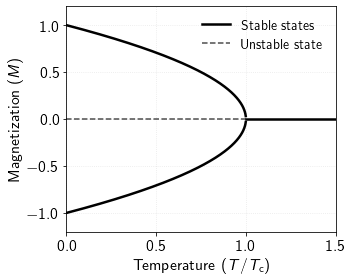

In [3]:
T = np.linspace(0, 2, 1000)  # Temperature normalized by T_c
m_plus = np.zeros_like(T)
m_minus = np.zeros_like(T)

mask = T < 1.0
m_plus[mask] = (1 - T[mask])**0.5
m_minus[mask] = -(1 - T[mask])**0.5

fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(T[~mask], np.zeros_like(T[~mask]), 'k-', linewidth=2.5)
ax.plot(T[mask], m_plus[mask], 'k-', linewidth=2.5, label='Stable states')
ax.plot(T[mask], m_minus[mask], 'k-', linewidth=2.5)
ax.plot(T[mask], np.zeros_like(T[mask]), 'k--', linewidth=1.5, alpha=0.7, 
        label='Unstable state')

ax.set_xlabel(r'Temperature $(T/T_\mathrm{c})$')
ax.set_ylabel(r'Magnetization $(M)$')
ax.set_xlim(0, 1.5)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, linestyle=':', alpha=0.3)

ax.legend(frameon = False, loc = "upper right", prop = {"size": 14})
plt.tight_layout()
plt.savefig('ferromagnet_phase.png', dpi=300, bbox_inches='tight', facecolor = "white")
plt.show()

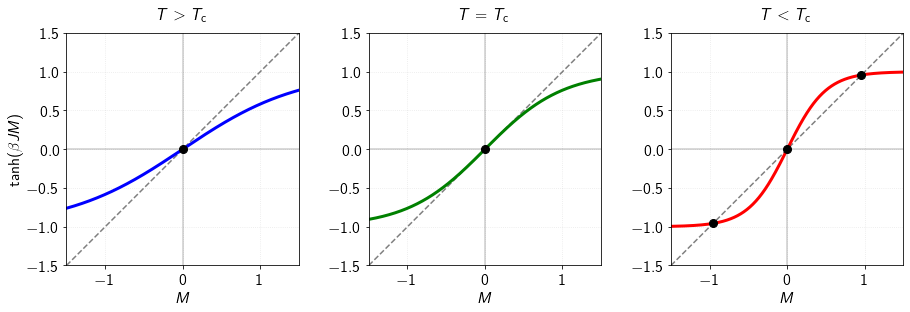

In [4]:
M = np.linspace(-1.5, 1.5, 1000)

T_high = 1.5    # T > Tc
T_c = 1.0       # T = Tc
T_low = 0.5     # T < Tc

def self_consistency(M, T, h=0):
    return np.tanh(M/T + h/T)

def find_intersections(T):
    from scipy.optimize import fsolve
    def equation(M):
        return M - np.tanh(M/T)
    
    if T < 1:  # For T < Tc, look for three solutions
        guesses = [-0.99, 0, 0.99]
        solutions = [fsolve(equation, guess)[0] for guess in guesses]
        return sorted(list(set([round(s, 6) for s in solutions])))
    else:  # For T ≥ Tc, look for one solution
        return [fsolve(equation, 0)[0]]

# Create the figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.3)

# Plot settings for all subplots
plot_settings = {
    'M_line_style': {'color': 'k', 'linestyle': '--', 'alpha': 0.5, 'label': r'$M$'},
    'tanh_line_style': {'linewidth': 3},
    'intersection_style': {'marker': 'o', 'markersize': 8, 'color': 'k', 'zorder': 3},
    'grid_style': {'linestyle': ':', 'alpha': 0.3},
}

def setup_subplot(ax, title, ylabel = True):
    ax.plot(M, M, **plot_settings['M_line_style'])
    ax.grid(True, **plot_settings['grid_style'])
    ax.set_xlabel(r'$M$')
    if ylabel:
        ax.set_ylabel(r'$\tanh(\beta JM)$')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(title, fontsize = 17, pad = 15)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)
    ax.set_aspect('equal')

# T > Tc plot
setup_subplot(ax1, r'$T > T_\mathrm{c}$')
ax1.plot(M, self_consistency(M, T_high), 'b-', **plot_settings['tanh_line_style'])
intersections = find_intersections(T_high)
for x in intersections:
    ax1.plot(x, x, **plot_settings['intersection_style'])

# T = Tc plot
setup_subplot(ax2, r'$T = T_\mathrm{c}$', False)
ax2.plot(M, self_consistency(M, T_c), 'g-', **plot_settings['tanh_line_style'])
intersections = find_intersections(T_c)
for x in intersections:
    ax2.plot(x, x, **plot_settings['intersection_style'])

# T < Tc plot
setup_subplot(ax3, r'$T < T_\mathrm{c}$', False)
ax3.plot(M, self_consistency(M, T_low), 'r-', **plot_settings['tanh_line_style'])
intersections = find_intersections(T_low)
for x in intersections:
    ax3.plot(x, x, **plot_settings['intersection_style'])

plt.savefig('self_consistency_separate.png', dpi=300, bbox_inches='tight', facecolor = "white")
plt.show()

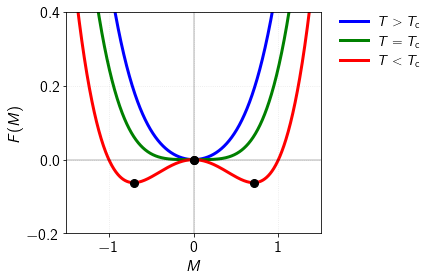

In [5]:
# Create temperature-dependent Landau free energy curves
M = np.linspace(-1.5, 1.5, 1000)

def landau_free_energy(M, T, h=0):
    # Coefficients
    a = (T - 1)  # (T-Tc)/Tc with Tc=1
    b = 1.0
    return 0.5*a*M**2 + 0.25*b*M**4 - h*M

# Create the figure
fig, ax = plt.subplots(figsize=(7, 4))

# Plot free energy for different temperatures
T_high = 1.5    # T > Tc
T_c = 1.0       # T = Tc
T_low = 0.5     # T < Tc

ax.plot(M, landau_free_energy(M, T_high), 'b-', label=r'$T > T_\mathrm{c}$', linewidth=3)
ax.plot(M, landau_free_energy(M, T_c), 'g-', label=r'$T = T_\mathrm{c}$', linewidth=3)
ax.plot(M, landau_free_energy(M, T_low), 'r-', label=r'$T < T_\mathrm{c}$', linewidth=3)

# Mark the minima with black dots
def find_minima(T):
    from scipy.optimize import fsolve
    def derivative(M):
        return (T - 1)*M + M**3
    
    if T < 1:  # Below Tc, three extrema (two minima, one maximum)
        guesses = [-1, 0, 1]
        solutions = [fsolve(derivative, guess)[0] for guess in guesses]
        return sorted(list(set([round(s, 6) for s in solutions])))
    else:  # Above Tc, one minimum
        return [0]

# Add dots at minima for each temperature
for T, color in [(T_high, 'b'), (T_c, 'g'), (T_low, 'r')]:
    minima = find_minima(T)
    for m in minima:
        if T < 1 and abs(m) < 0.1:  # Don't plot the maximum at M=0 for T < Tc
            continue
        ax.plot(m, landau_free_energy(m, T), 'ko', markersize=8, zorder=3)

ax.set_xlabel(r'$M$')
ax.set_ylabel(r'$F(M)$')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend(frameon=False, bbox_to_anchor = (1.45, 1.04), loc='upper right', prop = {"size": 14})
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.2, 0.4)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.savefig('landau_free_energy.png', dpi=300, bbox_inches='tight', facecolor = "white")
plt.show()

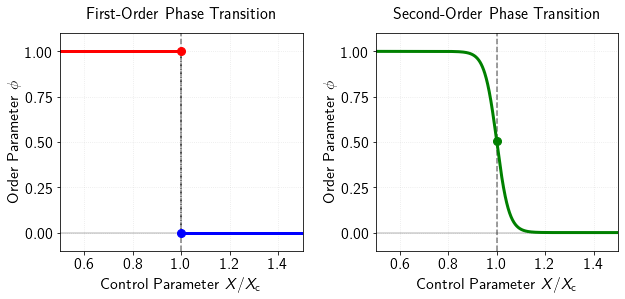

In [6]:
# Control parameter range
X = np.linspace(0.5, 1.5, 1000)
Xc = 1.0  # Critical point

# Create the figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

# Common plot settings
plot_settings = {
    'grid_style': {'linestyle': ':', 'alpha': 0.3},
    'main_line_style': {'linewidth': 3},
    'discontinuity_style': {'linestyle': ':', 'color': 'k', 'alpha': 0.7, 'linewidth': 1.5}
}

# Function to setup common elements for each subplot
def setup_subplot(ax, title):
    ax.grid(True, **plot_settings['grid_style'])
    ax.set_xlabel(r'Control Parameter $X/X_\mathrm{c}$')
    ax.set_ylabel(r'Order Parameter $\phi$')
    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(title, fontsize=17, pad=15)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=Xc, color='k', linestyle='--', alpha=0.5)
    
    # Add Xc label
    #ax.text(Xc + 0.02, -0.08, r'$X_\mathrm{c}$', fontsize=14)

# First-order phase transition with logistic-like curve but with discontinuity
setup_subplot(ax1, r'First-Order Phase Transition')

# Modified logistic function for first-order transition
def first_order_logistic(X, Xc=1.0, k=15):
    # We'll create two separate curves with a gap at Xc
    phi = np.zeros_like(X)
    
    # For X < Xc: Upper branch of logistic curve
    below_idx = X < Xc
    # Flipped logistic function that gradually decreases as X approaches Xc
    phi[below_idx] = 1.0 #1.0 / (1.0 + np.exp(k * (X[below_idx] - (Xc - 0.1))))
    
    # For X >= Xc: Lower branch that stays near zero
    # Using a very small logistic function to create a tiny bump from zero
    above_idx = X >= Xc
    phi[above_idx] = 0.0 #0.05 / (1.0 + np.exp(k * (X[above_idx] - (Xc + 0.2))))
    
    return phi

# Plot first-order transition
phi_first = first_order_logistic(X, Xc)
X_below = X[X <= Xc]
X_above = X[X >= Xc]
phi_below = phi_first[X <= Xc]
phi_above = phi_first[X >= Xc]

ax1.plot(X_below, phi_below, 'r-', **plot_settings['main_line_style'])
ax1.plot(X_above, phi_above, 'b-', **plot_settings['main_line_style'])

# Add points at the discontinuity
ax1.plot(Xc, phi_below[-1], 'ro', markersize=8, zorder=3)
ax1.plot(Xc, phi_above[0], 'bo', markersize=8, zorder=3)

# Add dotted line connecting the discontinuity
ax1.plot([Xc, Xc], [phi_above[0], phi_below[-1]], **plot_settings['discontinuity_style'])

# Second-order phase transition with flipped logistic curve
setup_subplot(ax2, r'Second-Order Phase Transition')

# Flipped logistic function for second-order transition
def second_order_logistic(X, Xc=1.0, k=40):
    phi = 1.0 / (1.0 + np.exp(k * (X - Xc)))
    return phi

# Plot second-order transition
phi_second = second_order_logistic(X, Xc)
ax2.plot(X, phi_second, 'g-', **plot_settings['main_line_style'])

# Add a point at the critical point
ax2.plot(Xc, phi_second[np.abs(X - Xc).argmin()], 'go', markersize=8, zorder=3)

plt.savefig('phase_transitions_comparison.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

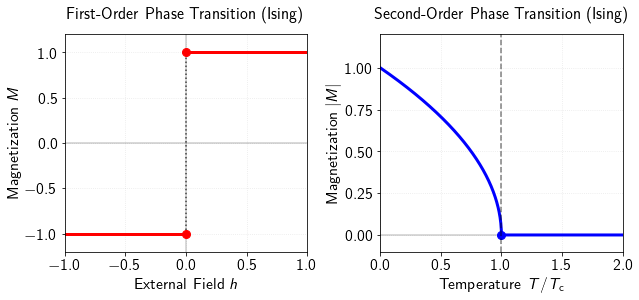

In [7]:
# Create the figure with subplots (swapping order)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

# Common plot settings
plot_settings = {
    'grid_style': {'linestyle': ':', 'alpha': 0.3},
    'main_line_style': {'linewidth': 3},
    'discontinuity_style': {'linestyle': ':', 'color': 'k', 'alpha': 0.7, 'linewidth': 1.5}
}

# Function to setup common elements for each subplot
def setup_subplot(ax, title, xlabel, ylabel):
    ax.grid(True, **plot_settings['grid_style'])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=17, pad=15)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)

# 1. First-order phase transition: Magnetization vs. External field (T<Tc)
# -----------------------------------------------------------------------
setup_subplot(ax1, r'First-Order Phase Transition (Ising)', 
              r'External Field $h$', 
              r'Magnetization $M$')

# External field range
h = np.linspace(-1.0, 1.0, 1000)
h0 = 0  # Critical field (h=0 for Ising)

# Create the step function for M vs h
h_sweep_neg = np.linspace(-1.0, 0, 500)
h_sweep_pos = np.linspace(0, 1.0, 500)

# Fixed magnetization values
M_neg = np.full_like(h_sweep_neg, -1.0)
M_pos = np.full_like(h_sweep_pos, 1.0)

# Plot the curves with the same color
ax1.plot(h_sweep_neg, M_neg, 'r-', **plot_settings['main_line_style'])
ax1.plot(h_sweep_pos, M_pos, 'r-', **plot_settings['main_line_style'])

# Dotted line for the discontinuity at h=0
ax1.plot([0, 0], [-1.0, 1.0], **plot_settings['discontinuity_style'])

# Add points at the discontinuity
ax1.plot(0, -1.0, 'ro', markersize=8, zorder=3)
ax1.plot(0, 1.0, 'ro', markersize=8, zorder=3)

# Set axis limits
ax1.set_xlim(-1.0, 1.0)
ax1.set_ylim(-1.2, 1.2)

# 2. Second-order phase transition: Magnetization vs. Temperature (h=0)
# ----------------------------------------------------------------------
setup_subplot(ax2, r'Second-Order Phase Transition (Ising)', 
              r'Temperature $T/T_\mathrm{c}$', 
              r'Magnetization $|M|$')

# Temperature range
T = np.linspace(0.0, 2.0, 1000)
Tc = 1.0  # Critical temperature

# Magnetization function for T<Tc (mean field approximation)
def magnetization(T, Tc=1.0, beta=0.5):
    M = np.zeros_like(T)
    # For T < Tc, M ~ (Tc-T)^beta near Tc
    below_idx = T < Tc
    M[below_idx] = (1.0 - T[below_idx]/Tc)**beta
    return M

# Calculate absolute magnetization
M_abs = magnetization(T, Tc)  # Only the positive branch since we're plotting |M|

# Plot only the absolute magnetization with a single color
ax2.plot(T, M_abs, 'b-', **plot_settings['main_line_style'])
ax2.plot(1.0, 0.0, 'bo', markersize=8)#, zorder=3)

# Add Tc line
ax2.axvline(x=Tc, color='k', linestyle='--', alpha=0.5)
#ax2.text(Tc + 0.05, -0.08, r'$T_\mathrm{c}$', fontsize=14)

# Set axis limits
ax2.set_xlim(0.0, 2.0)
ax2.set_ylim(-0.1, 1.2)

plt.savefig('ising_phase_transitions.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

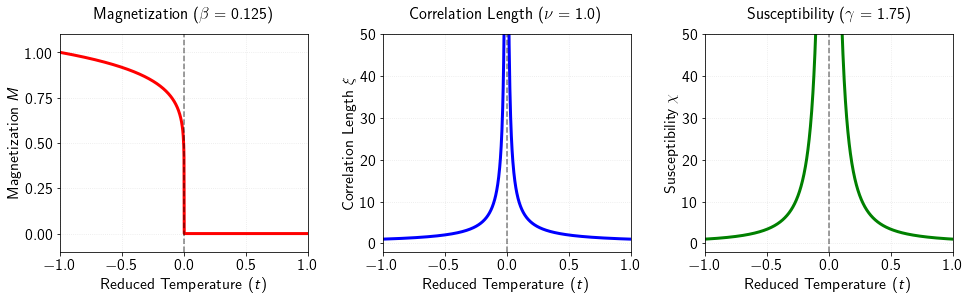

In [8]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
fig.subplots_adjust(wspace=0.3)

# Common plotting settings
plot_settings = {
    'grid_style': {'linestyle': ':', 'alpha': 0.3},
    'main_line_style': {'linewidth': 3},
    'tc_line_style': {'color': 'k', 'linestyle': '--', 'alpha': 0.5}
}

# Reduced temperature range
t = np.linspace(-1, 1, 1000)
t_neg = t[t < 0]  # t < 0 range
t_pos = t[t > 0]  # t > 0 range
tc = 0            # Critical point

# Critical exponents for 2D Ising model
beta = 0.125  # Magnetization exponent (= 1/8)
nu = 1.0      # Correlation length exponent
gamma = 1.75  # Susceptibility exponent (= 7/4)

# Helper function to set up subplot properties
def setup_subplot(ax, title, xlabel, ylabel, y_scale='linear'):
    ax.grid(True, **plot_settings['grid_style'])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=17, pad=15)
    ax.axvline(x=tc, **plot_settings['tc_line_style'])
    ax.text(tc + 0.05, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            r'$t_c$', fontsize=14)
    ax.set_yscale(y_scale)

# 1. Magnetization: M ~ |t|^β (t < 0)
# -------------------------------------------------------
magnetization = np.zeros_like(t)
magnetization[t < 0] = np.abs(t_neg)**beta

ax1.plot(t, magnetization, 'r-', **plot_settings['main_line_style'])
ax1.grid(True, **plot_settings['grid_style'])
ax1.set_xlabel(r'Reduced Temperature ($t$)')# $(t = \frac{T-T_c}{T_c})$')
ax1.set_ylabel(r'Magnetization $M$')
ax1.set_title(r'Magnetization ($\beta = %.3f$)' % beta, fontsize=17, pad=15)
ax1.axvline(x=tc, **plot_settings['tc_line_style'])
#ax1.text(tc + 0.05, -0.05, r'$t_c$', fontsize=14)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlim(-1, 1)

# 2. Correlation Length: ξ ~ |t|^(-ν)
# -------------------------------------------------------
corr_length = np.zeros_like(t)
# Define away from t=0 to avoid infinity
t_mask = (t < -0.01) | (t > 0.01)
corr_length[t_mask] = np.abs(t[t_mask])**(-nu)

ax2.plot(t[t < -0.01], corr_length[t < -0.01], 'b-', **plot_settings['main_line_style'])
ax2.plot(t[t > 0.01], corr_length[t > 0.01], 'b-', **plot_settings['main_line_style'])
ax2.grid(True, **plot_settings['grid_style'])
ax2.set_xlabel(r'Reduced Temperature ($t$)')# $(t = \frac{T-T_c}{T_c})$')
ax2.set_ylabel(r'Correlation Length $\xi$')
ax2.set_title(r'Correlation Length ($\nu = %.1f$)' % nu, fontsize=17, pad=15)
ax2.axvline(x=tc, **plot_settings['tc_line_style'])
#ax2.text(tc + 0.05, 0.5, r'$t_c$', fontsize=14)
#ax2.set_yscale('log')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-2, 50)

# 3. Susceptibility: χ ~ |t|^(-γ)
# -------------------------------------------------------
susceptibility = np.zeros_like(t)
# Define away from t=0 to avoid infinity
t_mask = (t < -0.01) | (t > 0.01)
susceptibility[t_mask] = np.abs(t[t_mask])**(-gamma)

ax3.plot(t[t < -0.01], susceptibility[t < -0.01], 'g-', **plot_settings['main_line_style'])
ax3.plot(t[t > 0.01], susceptibility[t > 0.01], 'g-', **plot_settings['main_line_style'])
ax3.grid(True, **plot_settings['grid_style'])
ax3.set_xlabel(r'Reduced Temperature ($t$)')# $(t = \frac{T-T_c}{T_c})$')
ax3.set_ylabel(r'Susceptibility $\chi$')
ax3.set_title(r'Susceptibility ($\gamma = %.2f$)' % gamma, fontsize=17, pad=15)
ax3.axvline(x=tc, **plot_settings['tc_line_style'])
#ax3.text(tc + 0.05, 0.5, r'$t_c$', fontsize=14)
#ax3.set_yscale('log')
ax3.set_xlim(-1, 1)
ax3.set_ylim(-2, 50)

plt.savefig('critical_exponents.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

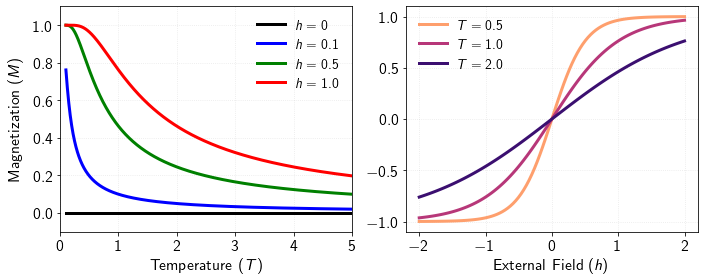

In [9]:
def sech(x):
    return 1 / np.cosh(x)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

# Common parameters
k_B = 1.0  # Boltzmann constant
T = np.linspace(0.1, 5, 1000)  # Temperature range
beta = 1.0 / (k_B * T)  # Inverse temperature

# Function to calculate magnetization for 1D Ising model
def magnetization_0d(beta, h):
    return np.tanh(beta * h)

# Function to calculate susceptibility directly
def susceptibility_0d(beta, h):
    # For 1D Ising model, there's a direct formula for susceptibility at h=0
    return beta * (sech(beta * h) ** 2)

# Calculate magnetization at different external fields
h_values = [0, 0.1, 0.5, 1.0]
colors = ['k', 'b', 'g', 'r']

# Plot magnetization vs temperature
for i, h in enumerate(h_values):
    M = magnetization_0d(beta, h)
    ax1.plot(T, M, color=colors[i], linewidth=3, 
             label=r'$h = {}$'.format(h))

# Calculate susceptibility at zero field using the exact formula
chi = susceptibility_0d(beta, h)

# Formatting for magnetization plot
ax1.set_xlabel(r'Temperature $(T)$')#, labelpad = 200)
ax1.set_ylabel(r'Magnetization $(M)$', labelpad = 10)
#ax1.set_title('1D Ising Model Magnetization', fontsize=18)
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.set_xlim(0, 5)
ax1.set_ylim(-0.1, 1.1)
ax1.legend(frameon=False, fontsize=14, )
#ax1.legend(frameon=False, bbox_to_anchor = (1.45, 1.04), loc='upper right', prop = {"size": 14})

# Plot magnetization vs temperature
h = np.linspace(-2, 2, 100)
T_values = [0.5, 1, 2]
cmap = plt.get_cmap("magma")
colors = [cmap(0.8), cmap(0.5), cmap(0.2)]
for i, T in enumerate(T_values):
    T = np.ones_like(h) * T
    beta = 1 / T
    M = magnetization_0d(beta, h)
    ax2.plot(h, M, color=colors[i], linewidth=3,  label=r'$T = {}$'.format(T[0]))

#ax2.set_xlabel(r'Temperature $(T)$')
ax2.set_xlabel(r'External Field $(h)$')
#ax2.set_ylabel(r'Magnetization $(M)$', labelpad = 10)
#ax1.set_title('1D Ising Model Magnetization', fontsize=18)
ax2.grid(True, linestyle=':', alpha=0.3)
#ax2.set_xlim(0, 5)
#ax2.set_ylim(-0.1, 1.1)
ax2.legend(frameon=False, fontsize=14, )

plt.tight_layout()
plt.savefig('ising_0d_results.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

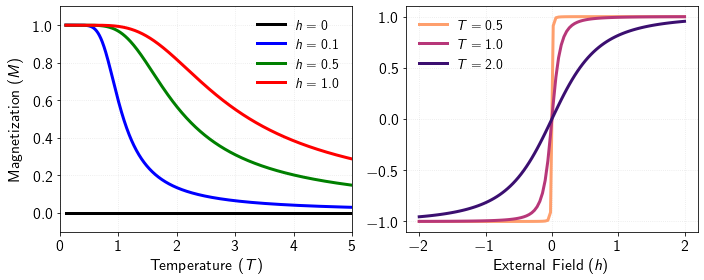

In [11]:
def sech(x):
    return 1 / np.cosh(x)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

# Common parameters
J = 1
k_B = 1.0  # Boltzmann constant
T = np.linspace(0.1, 5, 1000)  # Temperature range
beta = 1.0 / (k_B * T)  # Inverse temperature

# Calculate magnetization at different external fields
h_values = [0, 0.1, 0.5, 1.0]
colors = ['k', 'b', 'g', 'r']

# Function to calculate magnetization for 1D Ising model
def magnetization_1d(beta, h, J):
    return np.sinh(beta * h) / np.sqrt(np.sinh(beta * h)**2 + np.exp(-4 * beta * J))

# Function to calculate effective field (for susceptibility calculation)
def H_eff(beta, h, J):
    return h + J * magnetization_1d(beta, h, J)

# Function to calculate susceptibility
def susceptibility_1d(beta, h, J):
    H = H_eff(beta, h, J)
    return beta * (1 - np.tanh(beta * H)**2) / (1 - beta * J * (1/np.cosh(beta * H))**2)

# Plot magnetization vs temperature
for i, h in enumerate(h_values):
    M = magnetization_1d(beta, h, J)
    ax1.plot(T, M, color=colors[i], linewidth=3, 
             label=r'$h = {}$'.format(h))

# Calculate susceptibility at zero field using the exact formula
chi = susceptibility_0d(beta, h)

# Formatting for magnetization plot
ax1.set_xlabel(r'Temperature $(T)$')#, labelpad = 200)
ax1.set_ylabel(r'Magnetization $(M)$', labelpad = 10)
#ax1.set_title('1D Ising Model Magnetization', fontsize=18)
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.set_xlim(0, 5)
ax1.set_ylim(-0.1, 1.1)
ax1.legend(frameon=False, fontsize=14, )
#ax1.legend(frameon=False, bbox_to_anchor = (1.45, 1.04), loc='upper right', prop = {"size": 14})

# Plot magnetization vs temperature
h = np.linspace(-2, 2, 100)
T_values = [0.5, 1, 2]
cmap = plt.get_cmap("magma")
colors = [cmap(0.8), cmap(0.5), cmap(0.2)]
for i, T in enumerate(T_values):
    T = np.ones_like(h) * T
    beta = 1 / T
    M = magnetization_1d(beta, h, J)
    ax2.plot(h, M, color=colors[i], linewidth=3,  label=r'$T = {}$'.format(T[0]))

#ax2.set_xlabel(r'Temperature $(T)$')
ax2.set_xlabel(r'External Field $(h)$')
#ax2.set_ylabel(r'Magnetization $(M)$', labelpad = 10)
#ax1.set_title('1D Ising Model Magnetization', fontsize=18)
ax2.grid(True, linestyle=':', alpha=0.3)
#ax2.set_xlim(0, 5)
#ax2.set_ylim(-0.1, 1.1)
ax2.legend(frameon=False, fontsize=14, )

plt.tight_layout()
plt.savefig('ising_1d_results.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

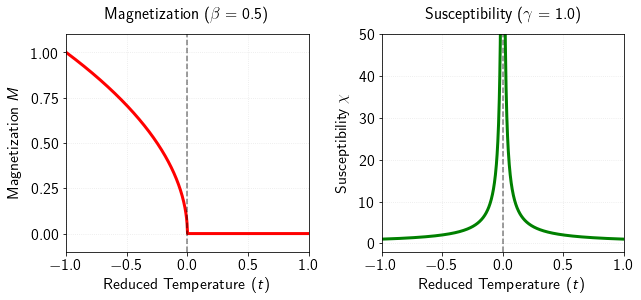

In [12]:
# MFT critical exponenents

# Set up LaTeX rendering and font sizes
plt.rcParams.update({
    "text.usetex": True,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "text.latex.preamble": r"\usepackage{sfmath}"
})

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

# Common plotting settings
plot_settings = {
    'grid_style': {'linestyle': ':', 'alpha': 0.3},
    'main_line_style': {'linewidth': 3},
    'tc_line_style': {'color': 'k', 'linestyle': '--', 'alpha': 0.5}
}

# Reduced temperature range
t = np.linspace(-1, 1, 1000)
t_neg = t[t < 0]  # t < 0 range
t_pos = t[t > 0]  # t > 0 range
tc = 0            # Critical point

# Critical exponents for Mean-Field Theory Ising model
beta = 0.5    # Magnetization exponent
gamma = 1.0   # Susceptibility exponent

# 1. Magnetization: M ~ |t|^β (t < 0) where β = 1/2 for MFT
# -------------------------------------------------------
magnetization = np.zeros_like(t)
magnetization[t < 0] = np.abs(t_neg)**beta

ax1.plot(t, magnetization, 'r-', **plot_settings['main_line_style'])
ax1.grid(True, **plot_settings['grid_style'])
ax1.set_xlabel(r'Reduced Temperature ($t$)')
ax1.set_ylabel(r'Magnetization $M$', labelpad = 10)
ax1.set_title(r'Magnetization ($\beta = %.1f$)' % beta, fontsize=17, pad=15)
ax1.axvline(x=tc, **plot_settings['tc_line_style'])
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlim(-1, 1)

# 2. Susceptibility: χ ~ |t|^(-γ) where γ = 1 for MFT
# -------------------------------------------------------
susceptibility = np.zeros_like(t)
# Define away from t=0 to avoid infinity
t_mask = (t < -0.01) | (t > 0.01)
susceptibility[t_mask] = np.abs(t[t_mask])**(-gamma)

ax2.plot(t[t < -0.01], susceptibility[t < -0.01], 'g-', **plot_settings['main_line_style'])
ax2.plot(t[t > 0.01], susceptibility[t > 0.01], 'g-', **plot_settings['main_line_style'])
ax2.grid(True, **plot_settings['grid_style'])
ax2.set_xlabel(r'Reduced Temperature ($t$)')
ax2.set_ylabel(r'Susceptibility $\chi$', labelpad = 10)
ax2.set_title(r'Susceptibility ($\gamma = %.1f$)' % gamma, fontsize=17, pad=15)
ax2.axvline(x=tc, **plot_settings['tc_line_style'])
ax2.set_xlim(-1, 1)
ax2.set_ylim(-2, 50)

plt.savefig('mft_critical_exponents.png', dpi=300, bbox_inches='tight', facecolor="white")
plt.show()